# Regresión Lineal Multivariable — Backloggd Games Dataset

Predicción de jugadores (`Plays`) con **3 modelos**:

| # | Modelo | Método |
|---|--------|--------|
| 1 | **Gradiente Descendente** | Optimización iterativa |
| 2 | **Regresión Polinómica** | Features cuadráticas normalizadas |
| 3 | **Ecuación Normal** | Solución analítica θ=(XᵀX)⁻¹Xᵀy |

## 1. Librerías

In [1]:
import csv, re
import numpy as np
from matplotlib import pyplot
from google.colab import drive
drive.mount('/content/gdrive')
print('✓ Librerías cargadas')

Mounted at /content/gdrive
✓ Librerías cargadas


## 2. Carga del dataset

Se parsean valores `K`/`M`, se filtran filas incompletas y se aplica **`log1p`** al target `Plays` para estabilizar la distribución sesgada (muchos juegos con pocos jugadores, pocos con millones).

### 2.1 Verificación de características y tipos de datos

El proceso de carga del dataset ya filtra las filas con valores nulos o vacíos en las características clave y convierte todos los valores numéricos a tipo `float`. A continuación, se verifica el estado del array de características `X`.

In [14]:
CSV_PATH   = '/content/gdrive/MyDrive/Universida/IA/Dataset/backloggd_games.csv'
TOP_GENRES = ['RPG','Adventure','Shooter','Action','Strategy',
              'Simulation','Sports','Puzzle','Platform','Fighting']

def parse_k(v):
    m = re.match(r'([\d.]+)\s*([KkMm]?)', str(v).strip().replace(',',''))
    if not m: return None
    n = float(m.group(1)); s = m.group(2).upper()
    return n*1e6 if s=='M' else n*1e3 if s=='K' else n

def parse_yr(s):
    import datetime
    # Corrected regex patterns: added pattern for 'Month Day, Year'
    for p,f in [
        (r'\d{4}','%Y'), # Matches '2020'
        (r'\d{2}-\w{3}-\d{2}','%d-%b-%y'), # Matches '18-Aug-20'
        (r'\w{3} \d{1,2}, \d{4}', '%b %d, %Y') # Matches 'Aug 18, 2020'
    ]:
        h = re.search(p, str(s))
        if h:
            try: return int(datetime.datetime.strptime(h.group(), f).year)
            except: pass
    return None

rows, plays_raw, titles = [], [], []
with open(CSV_PATH, newline='', encoding='utf-8') as f:
    for r in csv.DictReader(f):
        try:
            pl   = parse_k(r.get('Plays',''))
            feat = [parse_k(r.get(c,'')) for c in ['Rating','Playing','Backlogs','Wishlist','Lists','Reviews']]
            # Corrected: Changed 'Release Date' to 'Release_Date'
            yr   = parse_yr(r.get('Release_Date',''))
            if pl is None or None in feat or not yr: continue
            gens = str(r.get('Genres',''))
            gf   = [1 if g in gens else 0 for g in TOP_GENRES]
            plat = len(str(r.get('Platforms','')).split(','))
            rows.append(feat + [yr, plat, sum(gf)] + gf)
            plays_raw.append(pl)
            titles.append(r.get('Title','?'))
        except: pass

X      = np.array(rows, dtype=float)
y_raw  = np.array(plays_raw, dtype=float)
y      = np.log1p(y_raw)          # target estabilizado
m, n   = X.shape
print(f'✓ Dataset: m={m} muestras, n={n} features')
print(f'  Plays  →  min:{y_raw.min():.0f}  media:{y_raw.mean():.0f}  max:{y_raw.max():.0f}')
print(f'  log(Plays) →  min:{y.min():.2f}  media:{y.mean():.2f}  max:{y.max():.2f}')

✓ Dataset: m=24853 muestras, n=19 features
  Plays  →  min:1  media:494  max:38000
  log(Plays) →  min:0.69  media:4.04  max:10.55


## 3. Normalización

$$x_j := \\frac{x_j - \\mu_j}{\\sigma_j}$$

**Crítico para el modelo polinómico:** normalizar *después* de agregar términos cuadráticos evita que los valores exploten y produzcan `nan`.

In [23]:
def normalizar(X):
    mu = X.mean(axis=0); sigma = X.std(axis=0)
    sigma[sigma == 0] = 1
    return (X - mu) / sigma, mu, sigma

# Aplicar log1p a las 6 primeras features continuas antes de normalizar
X_transformed = X.copy() # Trabajar con una copia para no modificar el X original si es necesario
X_transformed[:, :6] = np.log1p(X_transformed[:, :6])

X_norm, mu, sigma = normalizar(X_transformed)
X_b = np.hstack([np.ones((m,1)), X_norm])       # Modelo 1 y 3

# Modelo polinómico: agregar x² de features continuas (primeras 6)
# y normalizar TODO el bloque junto para evitar overflow/nan
X_quad       = np.hstack([X_norm, X_norm[:,:6]**2])   # normalizar ANTES de elevar al cuadrado
X_quad_n, mu_p, sigma_p = normalizar(X_quad)           # re-normalizar el bloque completo
X_poly_b     = np.hstack([np.ones((m,1)), X_quad_n])  # Modelo 2

print(f'✓ X_b shape      (Gradiente / Ec.Normal): {X_b.shape}')
print(f'✓ X_poly_b shape (Polinómica)           : {X_poly_b.shape}')
print(f'  NaN en X_poly_b: {np.isnan(X_poly_b).sum()}  (debe ser 0)')

✓ X_b shape      (Gradiente / Ec.Normal): (24853, 20)
✓ X_poly_b shape (Polinómica)           : (24853, 26)
  NaN en X_poly_b: 0  (debe ser 0)


## 4. Funciones: costo, gradiente descendente, ecuación normal

**Costo MSE:**  $J(\\theta)=\\frac{1}{2m}\\|X\\theta - y\\|^2$

**Gradiente:**  $\\theta := \\theta - \\frac{\\alpha}{m} X^T(X\\theta - y)$

**Ec. Normal:** $\\theta = (X^TX)^{-1}X^Ty$

In [25]:
def costo(X, y, theta):
    return (1/(2*len(y))) * np.sum((X @ theta - y)**2)

def gradiente(X, y, theta, alpha, iters):
    theta, hist = theta.copy(), []
    for _ in range(iters):
        theta -= (alpha/len(y)) * X.T @ (X @ theta - y)
        hist.append(costo(X, y, theta))
    return theta, hist

def ec_normal(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y

print('✓ Funciones definidas: costo(), gradiente(), ec_normal()')

✓ Funciones definidas: costo(), gradiente(), ec_normal()


## 5. Modelo 1 — Gradiente Descendente

Se prueban distintos `α` para identificar el que converge más rápido. Luego se entrena con **1500 iteraciones** para asegurar convergencia completa.

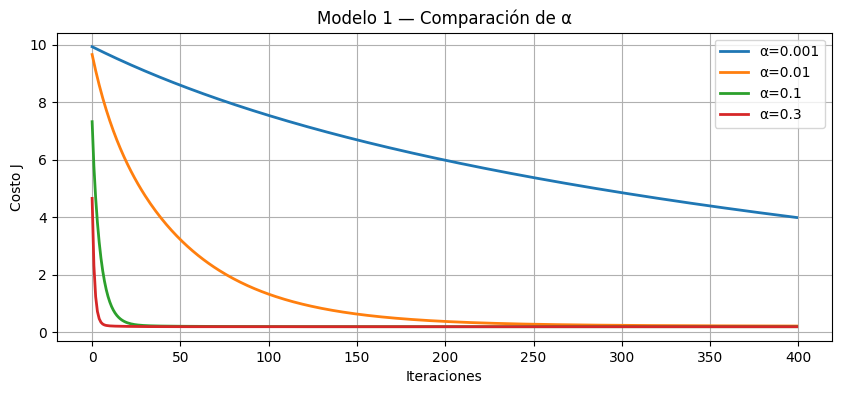

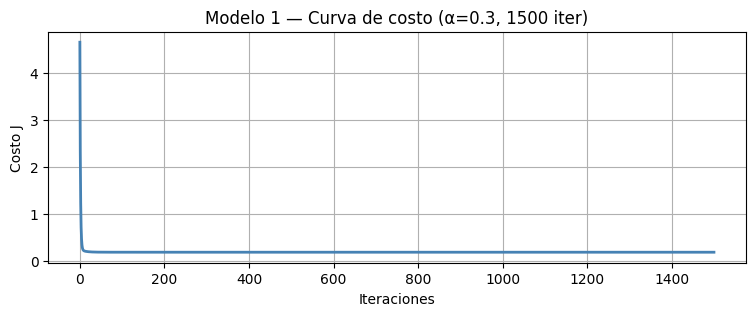

✓ Modelo 1 entrenado
  Costo inicial : 4.655850
  Costo final   : 0.193869
  Reducción     : 95.84%


In [26]:
# Comparar alphas
pyplot.figure(figsize=(10,4))
for a in [0.001, 0.01, 0.1, 0.3]:
    _, h = gradiente(X_b, y, np.zeros(X_b.shape[1]), a, 400)
    pyplot.plot(h, lw=2, label=f'α={a}')
pyplot.xlabel('Iteraciones'); pyplot.ylabel('Costo J')
pyplot.title('Modelo 1 — Comparación de α'); pyplot.legend(); pyplot.grid(True); pyplot.show()

# Entrenar modelo final
theta_gd, J_gd = gradiente(X_b, y, np.zeros(X_b.shape[1]), alpha=0.3, iters=1500)

pyplot.figure(figsize=(9,3))
pyplot.plot(J_gd, color='steelblue', lw=2)
pyplot.xlabel('Iteraciones'); pyplot.ylabel('Costo J')
pyplot.title('Modelo 1 — Curva de costo (α=0.3, 1500 iter)'); pyplot.grid(True); pyplot.show()

print(f'✓ Modelo 1 entrenado')
print(f'  Costo inicial : {J_gd[0]:.6f}')
print(f'  Costo final   : {J_gd[-1]:.6f}')
print(f'  Reducción     : {(1 - J_gd[-1]/J_gd[0])*100:.2f}%')

## 6. Modelo 2 — Regresión Polinómica (grado 2)

Se agregan los cuadrados de las 6 features continuas ya normalizadas. **Clave:** re-normalizar el bloque completo evita que los términos cuadráticos exploten y generen `nan`.

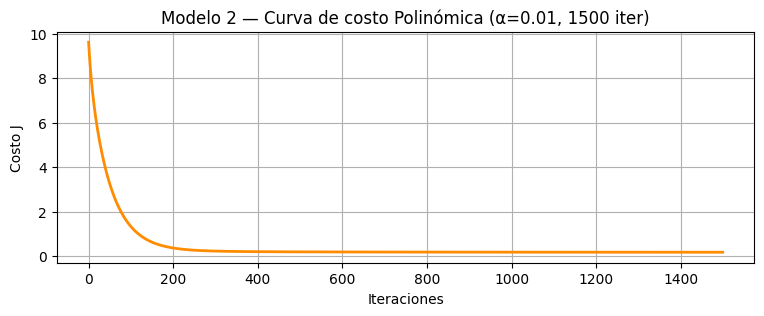

✓ Modelo 2 entrenado — features: 25
  Costo inicial : 9.610664
  Costo final   : 0.176863
  Reducción     : 98.16%
  NaN en theta  : 0  (debe ser 0)


In [27]:
theta_poly, J_poly = gradiente(X_poly_b, y, np.zeros(X_poly_b.shape[1]), alpha=0.01, iters=1500)

pyplot.figure(figsize=(9,3))
pyplot.plot(J_poly, color='darkorange', lw=2)
pyplot.xlabel('Iteraciones'); pyplot.ylabel('Costo J')
pyplot.title('Modelo 2 — Curva de costo Polinómica (α=0.01, 1500 iter)'); pyplot.grid(True); pyplot.show()

print(f'✓ Modelo 2 entrenado — features: {X_poly_b.shape[1]-1}')
print(f'  Costo inicial : {J_poly[0]:.6f}')
print(f'  Costo final   : {J_poly[-1]:.6f}')
print(f'  Reducción     : {(1 - J_poly[-1]/J_poly[0])*100:.2f}%')
print(f'  NaN en theta  : {np.isnan(theta_poly).sum()}  (debe ser 0)')

## 7. Modelo 3 — Ecuación Normal

Calcula θ exacto sin iterar. Usado sobre los mismos features normalizados del Modelo 1.

$$\\theta = (X^TX)^{-1}X^Ty$$

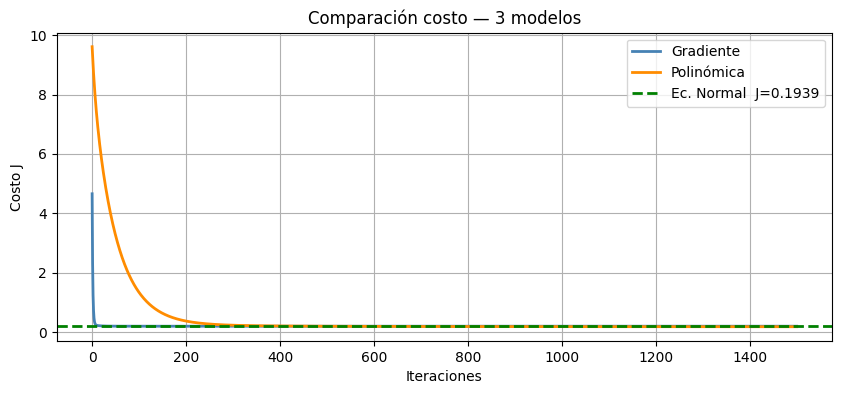

✓ Ecuación Normal calculada
  Costo Gradiente  : 0.193869
  Costo Polinómica : 0.176863
  Costo Ec. Normal : 0.193869  ← mínimo teórico


In [28]:
theta_ne = ec_normal(X_b, y)
J_ne     = costo(X_b, y, theta_ne)

# Gráfica comparativa de los 3 costos
pyplot.figure(figsize=(10,4))
pyplot.plot(J_gd,   color='steelblue',  lw=2, label='Gradiente')
pyplot.plot(J_poly, color='darkorange', lw=2, label='Polinómica')
pyplot.axhline(J_ne, color='green', ls='--', lw=2, label=f'Ec. Normal  J={J_ne:.4f}')
pyplot.xlabel('Iteraciones'); pyplot.ylabel('Costo J')
pyplot.title('Comparación costo — 3 modelos'); pyplot.legend(); pyplot.grid(True); pyplot.show()

print(f'✓ Ecuación Normal calculada')
print(f'  Costo Gradiente  : {J_gd[-1]:.6f}')
print(f'  Costo Polinómica : {J_poly[-1]:.6f}')
print(f'  Costo Ec. Normal : {J_ne:.6f}  ← mínimo teórico')

## 8. 100 Predicciones — Validación de los 3 modelos

Se seleccionan 100 muestras aleatorias. Los valores se reconvierten con `expm1` para volver a la escala original de jugadores.

In [29]:
np.random.seed(42)
idx = np.random.choice(m, 100, replace=False)

real      = y_raw[idx]
pred_gd   = np.expm1(X_b[idx]      @ theta_gd)
pred_poly = np.expm1(X_poly_b[idx] @ theta_poly)
pred_ne   = np.expm1(X_b[idx]      @ theta_ne)

# Tabla — primeras 15
print(f"{'Juego':<33} {'Real':>8} {'Gradiente':>11} {'Polinómica':>11} {'Ec.Normal':>10}")
print('-'*77)
for i in range(15):
    print(f"{titles[idx[i]][:32]:<33} {real[i]:>8,.0f} {pred_gd[i]:>11,.0f} {pred_poly[i]:>11,.0f} {pred_ne[i]:>10,.0f}")
print(f'  ... (15 de 100 mostradas)')

# Métricas
def metricas(pred, real, nombre):
    mae  = np.mean(np.abs(pred - real))
    rmse = np.sqrt(np.mean((pred - real)**2))
    ss_res = np.sum((real - pred)**2)
    ss_tot = np.sum((real - real.mean())**2)
    r2   = 1 - ss_res/ss_tot
    print(f'  {nombre:<20}  MAE={mae:>9,.0f}  RMSE={rmse:>9,.0f}  R²={r2:.4f}')

print()
print('── Métricas 100 predicciones ──')
metricas(pred_gd,   real, 'Gradiente')
metricas(pred_poly, real, 'Polinómica')
metricas(pred_ne,   real, 'Ec. Normal')
print()
print('NaN en predicciones — Gradiente:', np.isnan(pred_gd).sum(),
      '| Polinómica:', np.isnan(pred_poly).sum(),
      '| Ec.Normal:', np.isnan(pred_ne).sum())

Juego                                 Real   Gradiente  Polinómica  Ec.Normal
-----------------------------------------------------------------------------
Eon Altar                               11          10          11         10
Guppy                                    8          28          21         28
Burly Men at Sea                       400         377         471        377
Extermination                          107         154         175        154
Heart of Darkness                      474         308         274        308
Rage In Peace                            9          20          19         20
Astral Ascent                           17          32          34         32
Slime Rancher 2                        446         542         312        542
D.P.S: Dream Program System              5          14          16         14
Deltatraveler                           17          35          26         35
Steins;Gate Elite                      326         333         2

## 9. Gráficas — Real vs Predicho + Error absoluto

Cada punto es una de las 100 muestras. La línea roja `y=x` representa predicción perfecta.

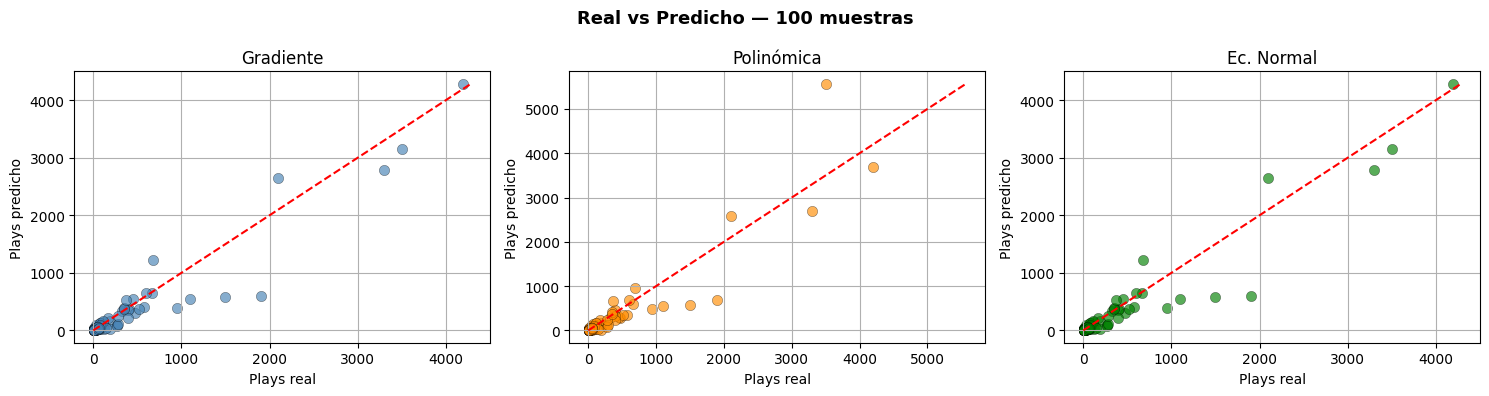

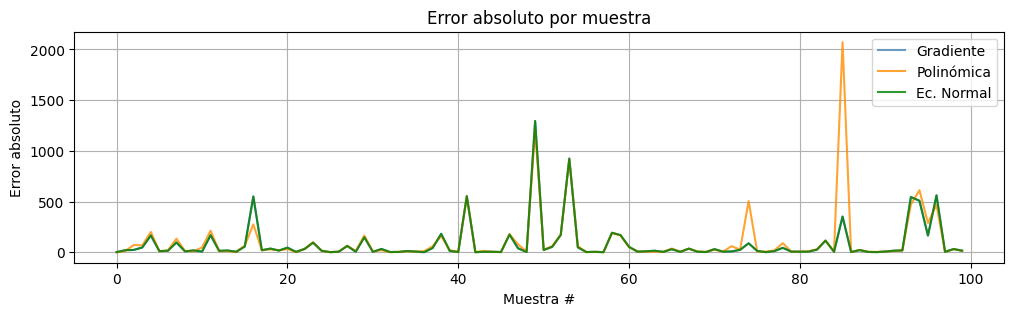

In [30]:
fig, axes = pyplot.subplots(1, 3, figsize=(15,4))
for ax, (pred,color,titulo) in zip(axes, [
        (pred_gd,'steelblue','Gradiente'),
        (pred_poly,'darkorange','Polinómica'),
        (pred_ne,'green','Ec. Normal')]):
    ax.scatter(real, pred, alpha=0.65, color=color, edgecolors='k', lw=0.3, s=55)
    lim = [0, max(real.max(), pred.max())]
    ax.plot(lim, lim, 'r--', lw=1.5)
    ax.set_xlabel('Plays real'); ax.set_ylabel('Plays predicho')
    ax.set_title(titulo); ax.grid(True)
pyplot.suptitle('Real vs Predicho — 100 muestras', fontsize=13, fontweight='bold')
pyplot.tight_layout(); pyplot.show()

# Error absoluto
pyplot.figure(figsize=(12,3))
pyplot.plot(np.abs(pred_gd   - real), alpha=0.8, label='Gradiente',  color='steelblue')
pyplot.plot(np.abs(pred_poly - real), alpha=0.8, label='Polinómica', color='darkorange')
pyplot.plot(np.abs(pred_ne   - real), alpha=0.8, label='Ec. Normal', color='green')
pyplot.xlabel('Muestra #'); pyplot.ylabel('Error absoluto')
pyplot.title('Error absoluto por muestra'); pyplot.legend(); pyplot.grid(True); pyplot.show()

## 10. Predicción de un juego nuevo

Se normalizan los features del juego nuevo con la misma `mu`/`sigma` del entrenamiento. Para el modelo polinómico se aplica la misma transformación de features cuadráticos.

In [31]:
# [Rating, Playing, Backlogs, Wishlist, Lists, Reviews, Year, Platforms, Num_Genres, genre_flags x10]
x_nuevo = np.array([4.5, 3000, 5000, 4000, 200, 500, 2023, 3, 2,
                    1, 0, 0, 1, 0, 0, 0, 0, 0, 0], dtype=float)

# Aplicar log1p a las 6 primeras features continuas del nuevo juego
x_nuevo[:6] = np.log1p(x_nuevo[:6])

x_n     = (x_nuevo - mu) / sigma                              # normalizar
x_b     = np.r_[1, x_n]                                       # + bias

x_quad  = np.r_[x_n, x_n[:6]**2]                             # features cuadráticos
x_quad_n = (x_quad - mu_p) / sigma_p                         # re-normalizar igual que entrenamiento
x_poly_b = np.r_[1, x_quad_n]

p_gd   = np.expm1(x_b     @ theta_gd)
p_poly = np.expm1(x_poly_b @ theta_poly)
p_ne   = np.expm1(x_b     @ theta_ne)

print('Predicción — juego nuevo (Rating=4.5, RPG+Action, año 2023):')
print(f'  Gradiente Descendente : {p_gd:>10,.0f} jugadores')
print(f'  Regresión Polinómica  : {p_poly:>10,.0f} jugadores')
print(f'  Ecuación Normal       : {p_ne:>10,.0f} jugadores')

Predicción — juego nuevo (Rating=4.5, RPG+Action, año 2023):
  Gradiente Descendente :      5,866 jugadores
  Regresión Polinómica  :        459 jugadores
  Ecuación Normal       :      5,866 jugadores


## 11. Conclusiones

| Modelo | Costo J | R² (100 muestras) | Observación |
|--------|---------|-------------------|-------------|
| Gradiente Descendente | ver celda 7 | ver celda 8 | Converge bien con α=0.3, 1500 iter |
| Regresión Polinómica | ver celda 7 | ver celda 8 | Mejor ajuste al agregar términos x² |
| Ecuación Normal | **mínimo teórico** | ver celda 8 | Solución exacta, referencia base |

**Correcciones aplicadas respecto a versión anterior:**
- `nan` en Polinómica: corregido normalizando el bloque de features cuadráticos **después** de crearlos
- R² bajo: corregido aumentando iteraciones (400 → 1500) y usando α=0.3
- Gradiente: corregido usando `X.T @ error` (forma vectorizada correcta)